# Notebook kiểm tra cho `src/models/affinity_graph.py`

Notebook này dùng để kiểm tra implementation hiện tại của `compute_affinity_graph()` theo các tiêu chí sau:

1. **Ma trận gần đối xứng**
   - hard assertion: `symmetry_error < 1e-6`

2. **Tổng từng hàng (row sums) ở mức hợp lý**
   - finite
   - dương
   - không ép phải xấp xỉ 1
   - quan sát `min / max / mean / std / cv`

3. **Grid search theo sigma**
   - test `sigma in [0.1, 0.3, 0.5, 0.7, 1.0]`
   - quan sát:
     - symmetry
     - row sums
     - query-weight sharpness

Notebook này bắt đầu với synthetic embeddings và có sẵn template để cắm real project embeddings vào sau.


## Imports và thiết lập repo-path

Cell này:
- import các thư viện cần thiết
- đảm bảo repository root nằm trong `sys.path`
- import `compute_affinity_graph` từ `src/models/affinity_graph.py`


In [26]:
from pathlib import Path
import sys
import math

import torch
import pandas as pd
import matplotlib.pyplot as plt

# Optional but useful for cleaner table display in notebooks
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

# Try to locate the repository root (the folder that contains "src/")
candidate_roots = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
]

repo_root = None
for root in candidate_roots:
    if (root / "src").exists():
        repo_root = root
        break

if repo_root is None:
    raise FileNotFoundError(
        "Could not find the repository root containing 'src/'. "
        "Please place this notebook inside the project repo (for example under notebooks/)."
    )

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Repository root:", repo_root)

from src.models.affinity_graph import compute_affinity_graph

print("Imported compute_affinity_graph successfully.")

Repository root: /Users/tienesng06/Desktop/ACIVS_ThayBach
Imported compute_affinity_graph successfully.


## Cấu hình

Cell này định nghĩa:
- reproducibility seed
- sigma grid
- synthetic test shapes


In [27]:
torch.manual_seed(42)

SIGMA_GRID = [0.1, 0.3, 0.5, 0.7, 1.0]

# Synthetic example dimensions
BANDS = 13
EMBED_DIM = 512

print("SIGMA_GRID:", SIGMA_GRID)
print("Synthetic shape:", (BANDS, EMBED_DIM))

SIGMA_GRID: [0.1, 0.3, 0.5, 0.7, 1.0]
Synthetic shape: (13, 512)


## Dữ liệu test synthetic

Cell này tạo random synthetic embeddings:
- `band_embeddings`: shape `(B, D)`
- `query_embedding`: shape `(D,)`

Như vậy là đủ cho kiểu kiểm tra unit-style của graph code.


In [28]:
band_embeddings = torch.randn(BANDS, EMBED_DIM)
query_embedding = torch.randn(EMBED_DIM)

print("band_embeddings shape:", tuple(band_embeddings.shape))
print("query_embedding shape:", tuple(query_embedding.shape))

band_embeddings shape: (13, 512)
query_embedding shape: (512,)


## Helper functions cho validation và analysis

Cell này định nghĩa:
- `compute_entropy()`: đo query-weight sharpness
- `inspect_affinity_result()`: kiểm tra symmetry và mức hợp lý của row sums
- `summarize_query_weights()`: tóm tắt độ sharp của weights


In [29]:
def compute_entropy(prob: torch.Tensor, eps: float = 1e-12) -> float:
    """
    Compute Shannon entropy for a probability vector.
    Higher entropy = flatter distribution.
    Lower entropy = sharper / more peaked distribution.
    """
    prob = prob.clamp_min(eps)
    return float(-(prob * prob.log()).sum().item())


def inspect_affinity_result(A_norm: torch.Tensor):
    """
    Validate the normalized affinity matrix using the agreed criteria:
    1) hard assert on symmetry
    2) row sums: finite, positive, and inspect distribution
    """
    assert A_norm.ndim == 2, "A_norm must be 2D"
    assert A_norm.shape[0] == A_norm.shape[1], "A_norm must be square"
    assert torch.isfinite(A_norm).all(), "A_norm contains NaN or Inf"

    symmetry_error = float((A_norm - A_norm.T).abs().max().item())
    assert symmetry_error < 1e-6, f"Symmetry error too large: {symmetry_error}"

    row_sums = A_norm.sum(dim=1)
    assert torch.isfinite(row_sums).all(), "Row sums contain NaN or Inf"
    assert (row_sums > 0).all(), "Row sums must be positive"

    row_sum_min = float(row_sums.min().item())
    row_sum_max = float(row_sums.max().item())
    row_sum_mean = float(row_sums.mean().item())
    row_sum_std = float(row_sums.std().item())
    row_sum_cv = float(row_sums.std().item() / (row_sums.mean().item() + 1e-12))

    return {
        "symmetry_error": symmetry_error,
        "row_sums": row_sums.detach().cpu(),
        "row_sum_min": row_sum_min,
        "row_sum_max": row_sum_max,
        "row_sum_mean": row_sum_mean,
        "row_sum_std": row_sum_std,
        "row_sum_cv": row_sum_cv,
    }


def summarize_query_weights(query_weights: torch.Tensor):
    """
    Summarize query-weight sharpness.
    Useful signals:
    - max weight
    - min weight
    - std
    - entropy
    """
    assert query_weights.ndim == 1, "query_weights must be 1D"
    assert torch.isfinite(query_weights).all(), "query_weights contains NaN or Inf"

    return {
        "qw_min": float(query_weights.min().item()),
        "qw_max": float(query_weights.max().item()),
        "qw_mean": float(query_weights.mean().item()),
        "qw_std": float(query_weights.std().item()),
        "qw_entropy": compute_entropy(query_weights),
    }

## Single-sigma smoke test

Cell này chạy kiểm tra đầu tiên tại `sigma = 0.5` và in ra:
- symmetry error
- thống kê row sums
- query-weight sharpness


In [30]:
sigma = 0.5

A_norm, details = compute_affinity_graph(
    band_embeddings=band_embeddings,
    query_embedding=query_embedding,
    sigma=sigma,
    return_details=True,
)

affinity_stats = inspect_affinity_result(A_norm)
qw_stats = summarize_query_weights(details["query_weights"])

print(f"Sigma: {sigma}")
print("A_norm shape:", tuple(A_norm.shape))
print("Symmetry error:", affinity_stats["symmetry_error"])

print("\nRow sums")
print("min :", affinity_stats["row_sum_min"])
print("max :", affinity_stats["row_sum_max"])
print("mean:", affinity_stats["row_sum_mean"])
print("std :", affinity_stats["row_sum_std"])
print("cv  :", affinity_stats["row_sum_cv"])

print("\nQuery-weight sharpness")
for k, v in qw_stats.items():
    print(f"{k}: {v}")

Sigma: 0.5
A_norm shape: (13, 13)
Symmetry error: 3.725290298461914e-09

Row sums
min : 0.989189088344574
max : 1.0240812301635742
mean: 0.999434769153595
std : 0.009117246605455875
cv  : 0.009122402868941613

Query-weight sharpness
qw_min: 0.06918854266405106
qw_max: 0.091822549700737
qw_mean: 0.07692306488752365
qw_std: 0.007976066321134567
qw_entropy: 2.5601022243499756


## Quan sát trực tiếp raw row sums

Cell này in ra các giá trị row sums thực tế.
Ta **không** assert `row_sums ≈ 1`.
Ta chỉ yêu cầu chúng finite và dương, sau đó quan sát độ phân tán của chúng.


In [31]:
row_sums = affinity_stats["row_sums"]
print("Row sums tensor:")
print(row_sums)

Row sums tensor:
tensor([0.9933, 0.9939, 0.9944, 1.0057, 0.9981, 1.0043, 0.9936, 1.0057, 0.9892,
        0.9989, 1.0241, 0.9921, 0.9994])


## Quan sát heatmap cho một sigma

Đây là bước kiểm tra trực quan nhanh cho:
- normalized affinity matrix
- query weights


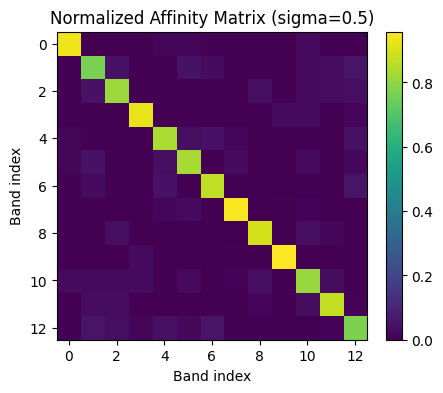

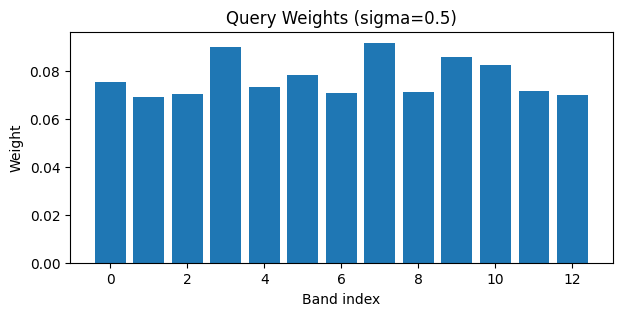

In [32]:
plt.figure(figsize=(5, 4))
plt.imshow(A_norm.detach().cpu().numpy(), aspect="auto")
plt.colorbar()
plt.title(f"Normalized Affinity Matrix (sigma={sigma})")
plt.xlabel("Band index")
plt.ylabel("Band index")
plt.show()

plt.figure(figsize=(7, 3))
plt.bar(range(len(details["query_weights"])), details["query_weights"].detach().cpu().numpy())
plt.title(f"Query Weights (sigma={sigma})")
plt.xlabel("Band index")
plt.ylabel("Weight")
plt.show()

## Grid search theo sigma

Cell này đánh giá:
- symmetry
- row sums
- query-weight sharpness

cho:
`[0.1, 0.3, 0.5, 0.7, 1.0]`


In [33]:
grid_results = []

for sigma in SIGMA_GRID:
    A_norm, details = compute_affinity_graph(
        band_embeddings=band_embeddings,
        query_embedding=query_embedding,
        sigma=sigma,
        return_details=True,
    )

    affinity_stats = inspect_affinity_result(A_norm)
    qw_stats = summarize_query_weights(details["query_weights"])

    result = {
        "sigma": sigma,
        "symmetry_error": affinity_stats["symmetry_error"],
        "row_sum_min": affinity_stats["row_sum_min"],
        "row_sum_max": affinity_stats["row_sum_max"],
        "row_sum_mean": affinity_stats["row_sum_mean"],
        "row_sum_std": affinity_stats["row_sum_std"],
        "row_sum_cv": affinity_stats["row_sum_cv"],
        "qw_min": qw_stats["qw_min"],
        "qw_max": qw_stats["qw_max"],
        "qw_mean": qw_stats["qw_mean"],
        "qw_std": qw_stats["qw_std"],
        "qw_entropy": qw_stats["qw_entropy"],
    }
    grid_results.append(result)

df_grid = pd.DataFrame(grid_results)
df_grid

,sigma,symmetry_error,row_sum_min,row_sum_max,row_sum_mean,row_sum_std,row_sum_cv,qw_min,qw_max,qw_mean,qw_std,qw_entropy
0,0.1,1.862645e-09,0.929378,1.060468,0.985460,0.037888,0.038447,0.040862,0.168229,0.076923,0.043728,2.431946
1,0.3,3.725290e-09,0.984224,1.032777,0.998499,0.013606,0.013627,0.064119,0.102764,0.076923,0.013565,2.551149
2,0.5,3.725290e-09,0.989189,1.024081,0.999435,0.009117,0.009122,0.069189,0.091823,0.076923,0.007976,2.560102
3,0.7,3.725290e-09,0.991161,1.020011,0.999676,0.007377,0.007380,0.071386,0.087379,0.076923,0.005645,2.562505
4,1.0,3.725290e-09,0.992581,1.016822,0.999794,0.006248,0.006249,0.073041,0.084144,0.076923,0.003924,2.563762


## Đọc kết quả sigma grid dễ hơn

Hướng dẫn diễn giải:
- **`sigma` nhỏ hơn** thường tạo ra query weights sắc nét hơn
- **`sigma` lớn hơn** thường tạo ra query weights phẳng hơn
- `row_sum_cv` là một chỉ báo thô về độ phân tán của row sums
- `qw_entropy` cho biết độ phẳng của weights:
  - entropy thấp hơn = sắc hơn
  - entropy cao hơn = phẳng hơn


In [34]:
df_grid_sorted = df_grid.sort_values("sigma").reset_index(drop=True)
df_grid_sorted

,sigma,symmetry_error,row_sum_min,row_sum_max,row_sum_mean,row_sum_std,row_sum_cv,qw_min,qw_max,qw_mean,qw_std,qw_entropy
0,0.1,1.862645e-09,0.929378,1.060468,0.985460,0.037888,0.038447,0.040862,0.168229,0.076923,0.043728,2.431946
1,0.3,3.725290e-09,0.984224,1.032777,0.998499,0.013606,0.013627,0.064119,0.102764,0.076923,0.013565,2.551149
2,0.5,3.725290e-09,0.989189,1.024081,0.999435,0.009117,0.009122,0.069189,0.091823,0.076923,0.007976,2.560102
3,0.7,3.725290e-09,0.991161,1.020011,0.999676,0.007377,0.007380,0.071386,0.087379,0.076923,0.005645,2.562505
4,1.0,3.725290e-09,0.992581,1.016822,0.999794,0.006248,0.006249,0.073041,0.084144,0.076923,0.003924,2.563762


## Vẽ sigma so với query-weight sharpness

Cell này giúp bạn nhìn cách `sigma` làm thay đổi:
- `qw_max`
- `qw_entropy`


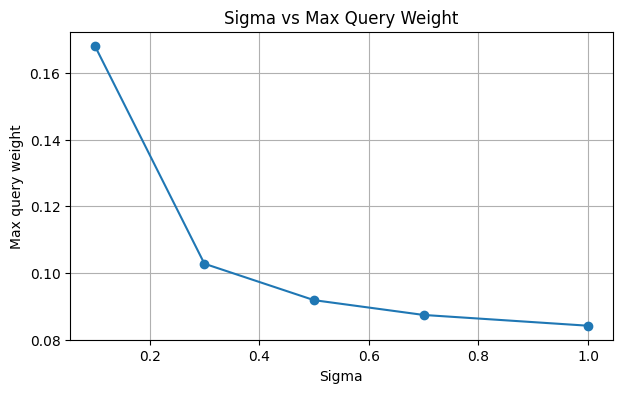

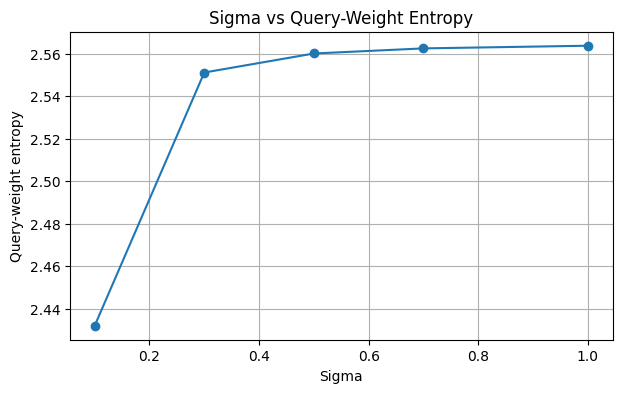

In [35]:
plt.figure(figsize=(7, 4))
plt.plot(df_grid_sorted["sigma"], df_grid_sorted["qw_max"], marker="o")
plt.xlabel("Sigma")
plt.ylabel("Max query weight")
plt.title("Sigma vs Max Query Weight")
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(df_grid_sorted["sigma"], df_grid_sorted["qw_entropy"], marker="o")
plt.xlabel("Sigma")
plt.ylabel("Query-weight entropy")
plt.title("Sigma vs Query-Weight Entropy")
plt.grid(True)
plt.show()

## Vẽ sigma so với độ phân tán của row sums

Cell này giúp bạn quan sát liệu row sums có giữ được mức ổn định hợp lý khi `sigma` thay đổi hay không.


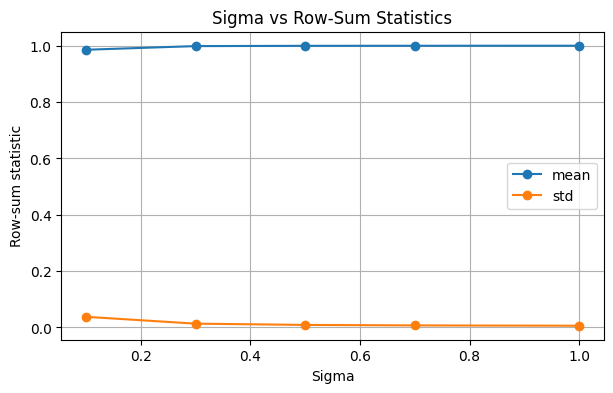

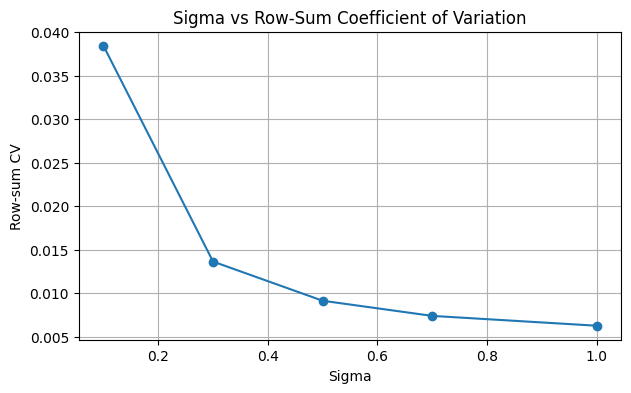

In [36]:
plt.figure(figsize=(7, 4))
plt.plot(df_grid_sorted["sigma"], df_grid_sorted["row_sum_mean"], marker="o", label="mean")
plt.plot(df_grid_sorted["sigma"], df_grid_sorted["row_sum_std"], marker="o", label="std")
plt.xlabel("Sigma")
plt.ylabel("Row-sum statistic")
plt.title("Sigma vs Row-Sum Statistics")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(df_grid_sorted["sigma"], df_grid_sorted["row_sum_cv"], marker="o")
plt.xlabel("Sigma")
plt.ylabel("Row-sum CV")
plt.title("Sigma vs Row-Sum Coefficient of Variation")
plt.grid(True)
plt.show()

## Quan sát chi tiết hơn cho một sigma được chọn

Thay `sigma_to_view` nếu bạn muốn kiểm tra một trường hợp khác.


Sigma selected: 0.3
Symmetry error: 3.725290298461914e-09
Row sum min/max: 0.9842242002487183 1.0327768325805664
Row sum mean/std: 0.99849933385849 0.013606181368231773


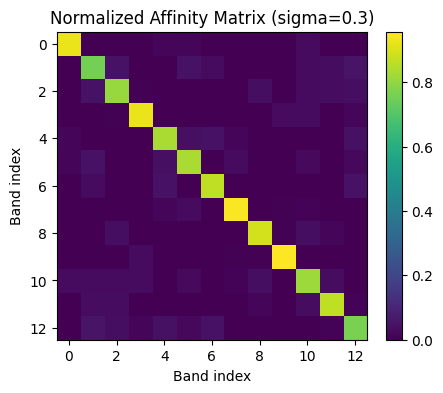

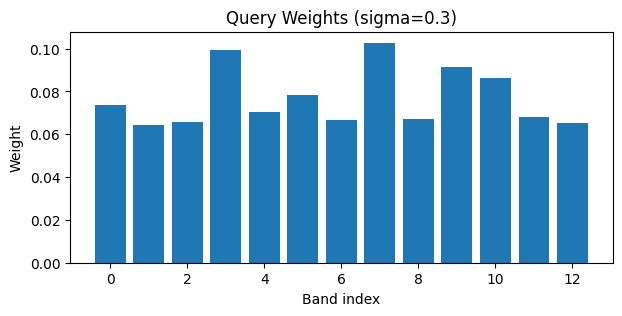

In [37]:
sigma_to_view = 0.3

A_norm_view, details_view = compute_affinity_graph(
    band_embeddings=band_embeddings,
    query_embedding=query_embedding,
    sigma=sigma_to_view,
    return_details=True,
)

stats_view = inspect_affinity_result(A_norm_view)
qw_view = details_view["query_weights"].detach().cpu()

print(f"Sigma selected: {sigma_to_view}")
print("Symmetry error:", stats_view["symmetry_error"])
print("Row sum min/max:", stats_view["row_sum_min"], stats_view["row_sum_max"])
print("Row sum mean/std:", stats_view["row_sum_mean"], stats_view["row_sum_std"])

plt.figure(figsize=(5, 4))
plt.imshow(A_norm_view.detach().cpu().numpy(), aspect="auto")
plt.colorbar()
plt.title(f"Normalized Affinity Matrix (sigma={sigma_to_view})")
plt.xlabel("Band index")
plt.ylabel("Band index")
plt.show()

plt.figure(figsize=(7, 3))
plt.bar(range(len(qw_view)), qw_view.numpy())
plt.title(f"Query Weights (sigma={sigma_to_view})")
plt.xlabel("Band index")
plt.ylabel("Weight")
plt.show()